# Explore here

In [5]:
# Your code here

import pandas as pd

url = "https://raw.githubusercontent.com/4GeeksAcademy/decision-tree-project-tutorial/main/diabetes.csv"
df = pd.read_csv(url)
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [8]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [9]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [35]:
df.shape

(768, 9)

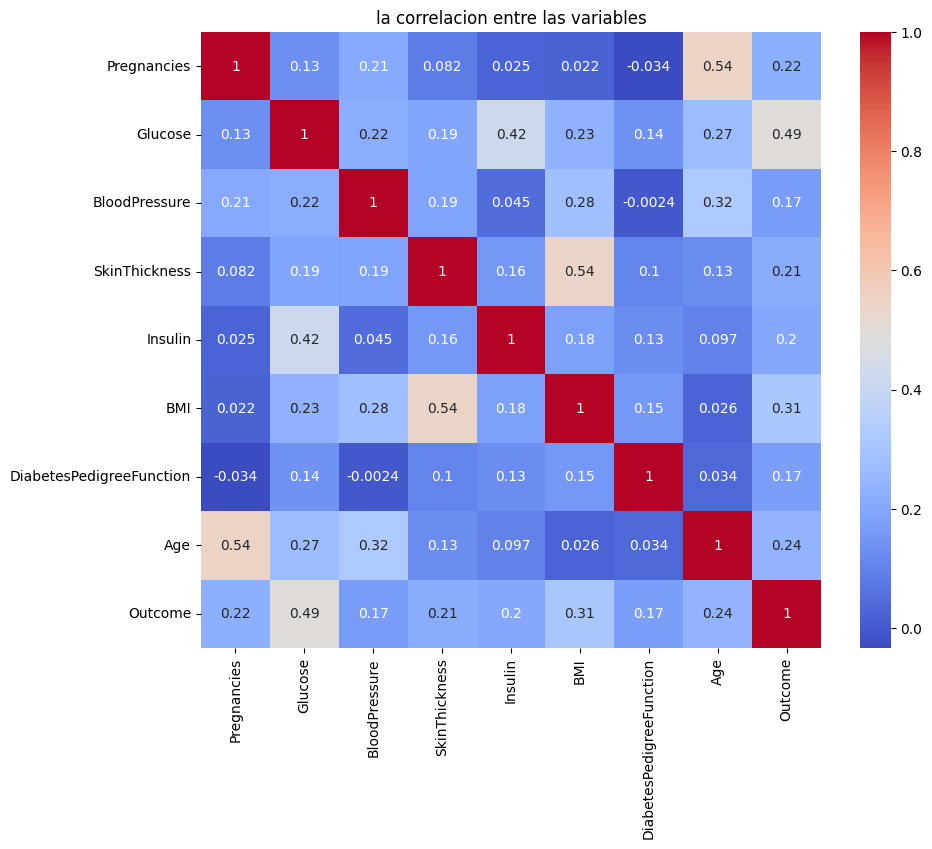

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("la correlacion entre las variables")
plt.show()

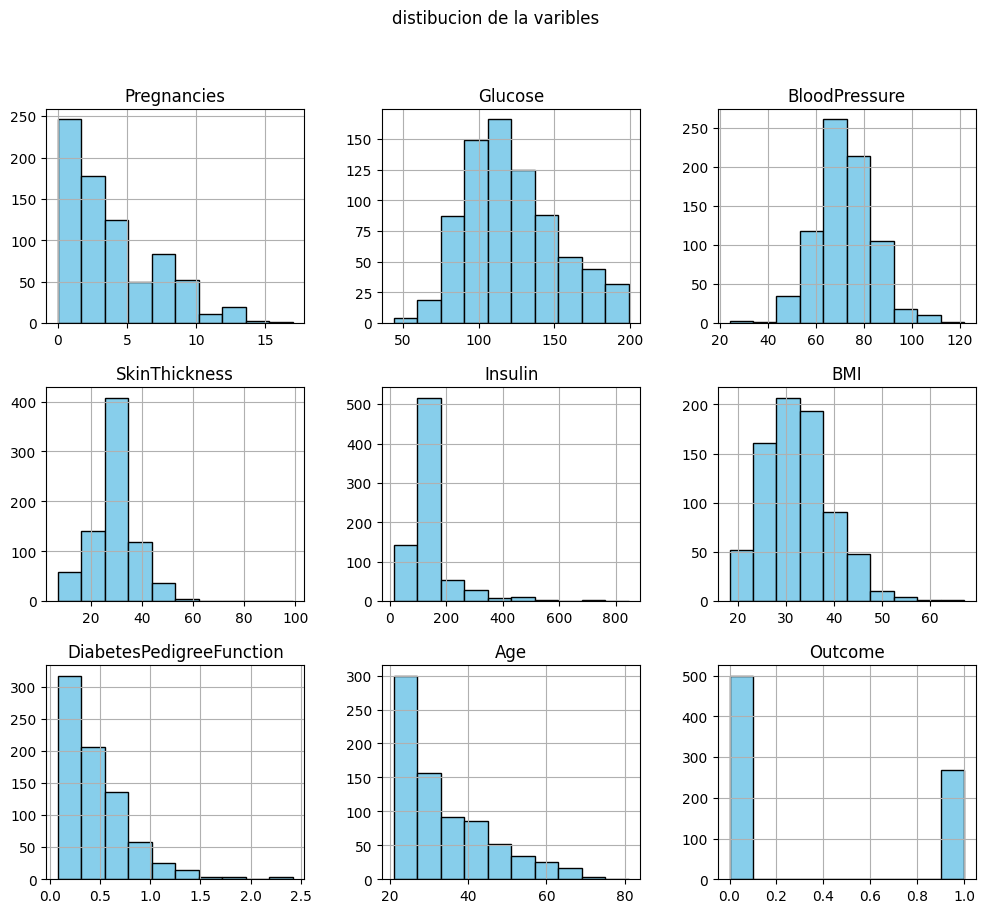

In [37]:
df.hist(figsize=(12,10), color="skyblue", edgecolor="black")
plt.suptitle("distibucion de la varibles")
plt.show()  

In [10]:
# Lista de columnas donde el 0 es físicamente imposible
cols_problema = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Contamos cuántos ceros hay en cada una
for col in cols_problema:
    conteo_ceros = (df[col] == 0).sum()
    print(f"Ceros en {col}: {conteo_ceros}")


Ceros en Glucose: 5
Ceros en BloodPressure: 35
Ceros en SkinThickness: 227
Ceros en Insulin: 374
Ceros en BMI: 11


In [ ]:
import numpy as np

cols_problema = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in cols_problema:
    df[col] = df[col].replace(0, np.nan)

for col in cols_problema:
    mediana_columna = df[col].median()
    df[col] = df[col].fillna(value=mediana_columna)

print("Nuevos valores mínimos tras la limpieza:")
print(df[cols_problema].min())


Nuevos valores mínimos tras la limpieza:
Glucose          44.0
BloodPressure    24.0
SkinThickness     7.0
Insulin          14.0
BMI              18.2
dtype: float64


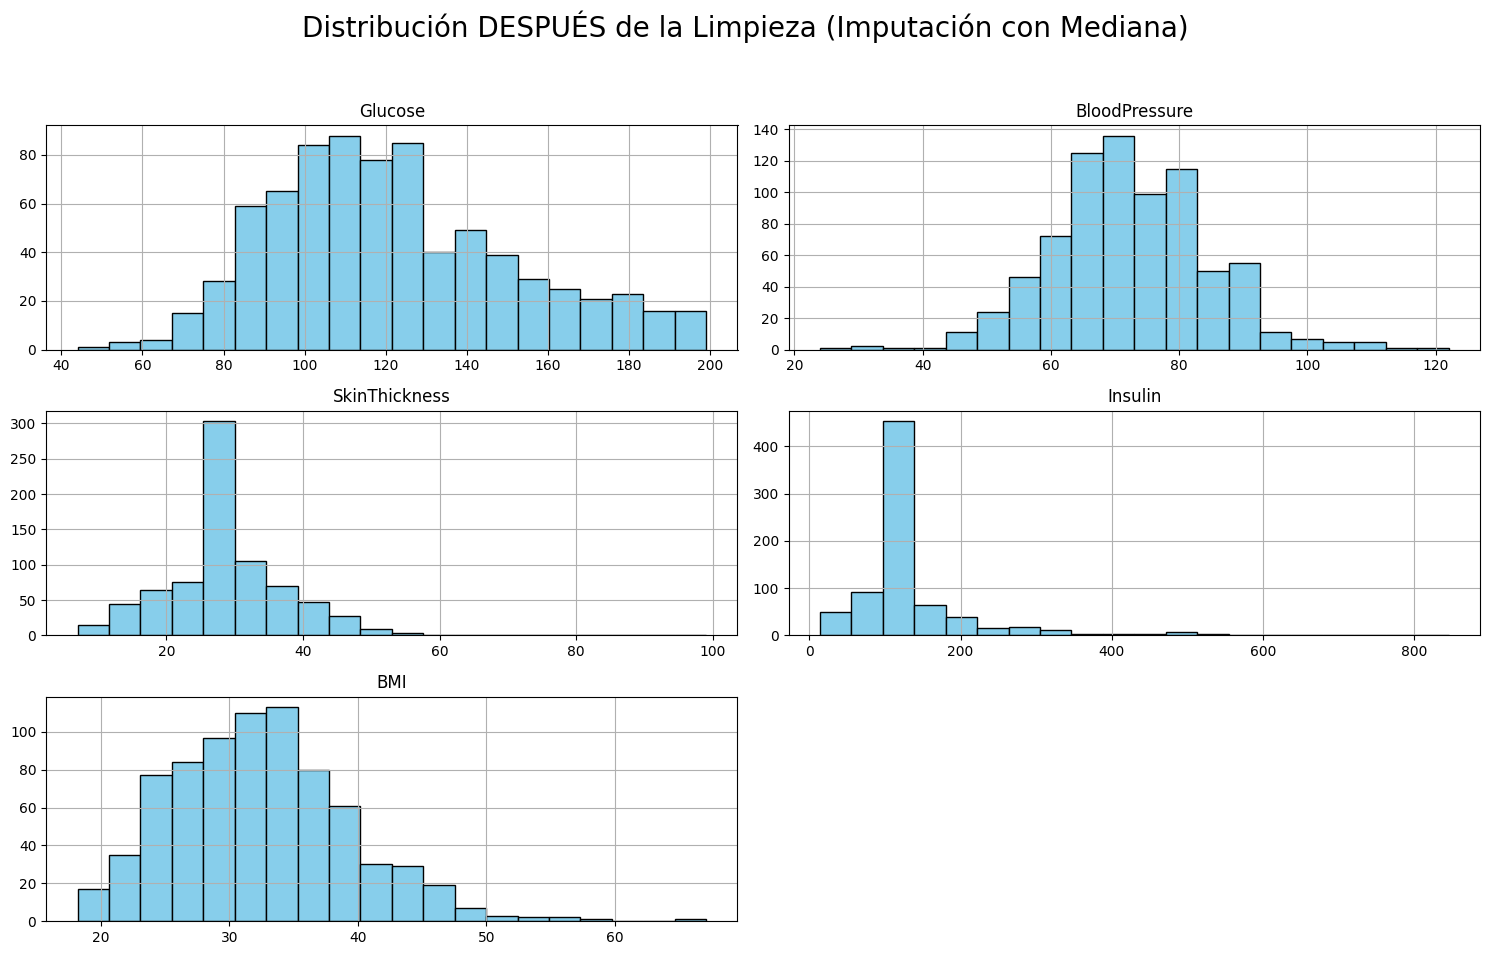

In [38]:
import matplotlib.pyplot as plt

# Seleccionamos las columnas que limpiamos
cols_limpias = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Creamos la figura
df[cols_limpias].hist(figsize=(15, 10), color="#87ceeb", edgecolor="black", bins=20)

plt.suptitle("Distribución DESPUÉS de la Limpieza (Imputación con Mediana)", fontsize=20)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [17]:
from sklearn.model_selection import train_test_split
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train,X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2, random_state=42
) 
print(f"Muestra de entrenamiento: {X_train.shape[0]} personas")
print(f"Muestra de prueba: {X_test.shape[0]} personas")


Muestra de entrenamiento: 614 personas
Muestra de prueba: 154 personas


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

y_train = y_train.astype(int)
y_test = y_test.astype(int)

model_boost = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

model_boost.fit(X_train, y_train)

y_pred = model_boost.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)


print(f"La precisión (Accuracy) es: {accuracy:.4f}")


La precisión (Accuracy) es: 0.7597


In [30]:
model_optimizado = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=.01,
    max_depth=3,
    random_state=42
)

model_optimizado.fit(X_train, y_train.astype(int))

y_pred_opt = model_optimizado.predict(X_test)

print(f"nueva precison: {accuracy_score(y_test.astype(int),y_pred_opt):.2f}")

nueva precison: 0.77


In [34]:
import pickle
import os

os.makedirs("models", exist_ok = True)
with open("models/boosting_diabetes_v1.pkl","wb") as archivo:
    pickle.dump(model_optimizado,archivo)

print("guardado")


guardado


En el df habia datos en cero lo que podia cambiar el resultado del modelo, por lo que tome la decicion de remplazarlos por el promedio (mean), ya que si quitamos la columna podriamos perder datos importantes que podrian ayudar a la toma de decision, despues de eso lo modelamos con un arbol de decicion a lo que nos dio .75 es bueno pero podria ser mejor, a lo que realizamos el boosting probamos muchos tipos de configuracion por ejemplo 200 arboles learning rate 0.05 lo que nos debolvio un valor mas bajo(.73) del primer modelo que era 75, esto indico un sobre ajuste, por lo que modificamos la configuracion a mas arboles (300) pero bajamos el aprendizaje a 0.01, ya con esta modificacion nos dio el resultado de .77, por lo que el modelo dio resultados mas entrenados